# Análise de Dados - E-commerce Olist

## Análise exploratória dos dados

Nesta etapa, os dados tratados serão analisados com o objetivo de identificar padrões, comportamentos e indicadores relevantes do e-commerce.

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

## Carregamento dos dados tratados

Nesta etapa, serão carregados os datasets tratados e preparados anteriormente para a realização das análises.

In [103]:
df_pedidos = pd.read_csv("../data/processed/pedidos.csv", parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

df_itens = pd.read_csv("../data/processed/itens.csv", parse_dates=["shipping_limit_date"])

df_pagamentos = pd.read_csv("../data/processed/pagamentos.csv")

df_avaliacoes = pd.read_csv("../data/processed/avaliacoes.csv", parse_dates=["review_creation_date", "review_answer_timestamp"])

df_produtos = pd.read_csv("../data/processed/produtos.csv")

## Perguntas de negócio

A análise exploratória será orientada por perguntas de negócio, buscando compreender o desempenho das vendas, o comportamento dos pedidos, as categorias de produtos, as formas de pagamento e a satisfação dos clientes.

### Questões que serão analisadas

1. Qual é o valor total vendido em produtos?
2. Quantos pedidos foram entregues e qual é o ticket médio em produtos?
3. Como as vendas evoluíram ao longo do tempo?
4. Quais categorias apresentam maior valor vendido em produtos?
5. Quais categorias possuem maior quantidade de itens vendidos?
6. Quais são as formas de pagamento mais utilizadas?
7. Como estão distribuídas as avaliações dos clientes?
8. Existe relação entre atraso na entrega e avaliação do cliente?

## Análise de vendas

> **Nota:** Nas análises de vendas, serão considerados apenas os pedidos entregues (delivered). O valor vendido corresponde à soma dos preços dos produtos (price), sem incluir o frete. Os valores são apresentados em reais (BRL).

### Valor total vendido em produtos

Para calcular o valor total dos produtos vendidos, será utilizada a coluna `price` do dataset de itens. Cada linha desse dataset representa um item associado a um pedido e contém o preço praticado naquela venda.

In [104]:
df_itens_status = df_itens.merge(df_pedidos[["order_id", "order_status"]], on="order_id", how="left")

In [105]:
# Quantidade de itens por status do pedido
df_itens_status["order_status"].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [106]:
df_itens_entregues = df_itens_status[df_itens_status["order_status"] == "delivered"]

faturamento_produtos = df_itens_entregues["price"].sum()

print(f"Valor total vendido em produtos: R${faturamento_produtos:,.2f}")

Valor total vendido em produtos: R$13,221,498.11


**Insight:** Considerando apenas os pedidos com status `delivered`, o valor total vendido em produtos foi de aproximadamente **R$ 13,22 milhões**.

### Quantidade de pedidos entregues e ticket médio em produtos

Nesta análise, serão considerados os pedidos entregues, mantendo o mesmo critério utilizado no cálculo do valor total vendido em produtos.

In [107]:
quantidade_pedidos = df_itens_entregues["order_id"].nunique()

print(f"Quantidade de pedidos entregues: {quantidade_pedidos}")

Quantidade de pedidos entregues: 96478


In [108]:
ticket_medio = faturamento_produtos / quantidade_pedidos

print(f"Ticket Médio em produtos: R${ticket_medio:,.2f}")

Ticket Médio em produtos: R$137.04


**Insight:** Foram identificados **96.478 pedidos entregues**, com um ticket médio de aproximadamente **R$ 137,04 em produtos por pedido**.

### Evolução das vendas ao longo do tempo

Nesta análise, será avaliada a evolução mensal do valor vendido em produtos, considerando apenas os pedidos entregues. Os valores serão agrupados pelo mês em que a compra foi realizada.

In [109]:
# Acrescenta a data da compra a cada item de pedido entregue
df_vendas_tempo = df_itens_entregues.merge(df_pedidos[["order_id", "order_purchase_timestamp"]], on="order_id", how="left")

In [110]:
# Extrai o ano e o mês da compra para agrupar as vendas mensalmente
df_vendas_tempo["ano_mes"] = df_vendas_tempo["order_purchase_timestamp"].dt.to_period("M")

In [111]:
df_vendas_mensais = df_vendas_tempo.groupby("ano_mes")["price"].sum().reset_index()

df_vendas_mensais = df_vendas_mensais.rename(columns={"price": "total_vendido"})

df_vendas_mensais

,ano_mes,total_vendido
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [112]:
df_vendas_mensais["total_vendido_milhoes"] = df_vendas_mensais["total_vendido"] / 1000000

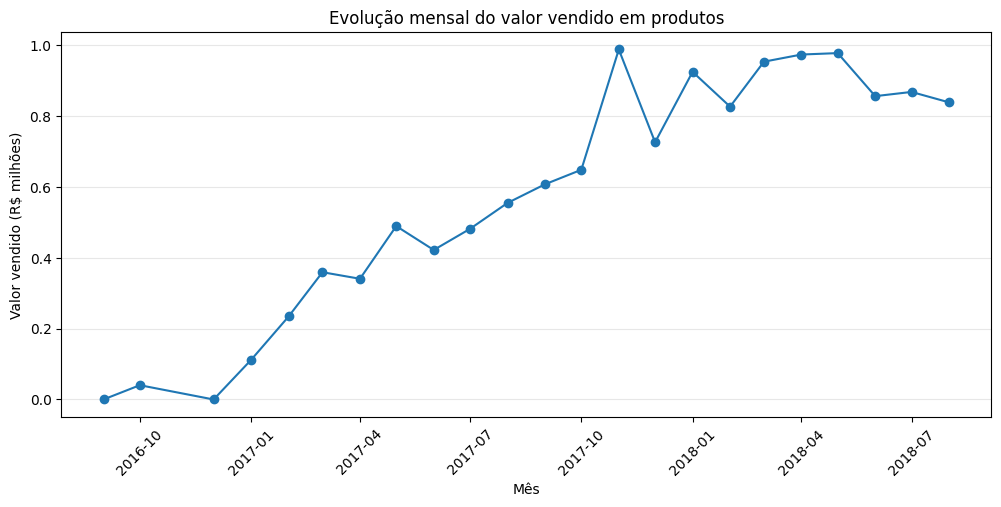

In [113]:
plt.figure(figsize=(12,5))

plt.plot(df_vendas_mensais["ano_mes"].dt.to_timestamp(), df_vendas_mensais["total_vendido_milhoes"], marker="o")

plt.title("Evolução mensal do valor vendido em produtos")
plt.xlabel("Mês")
plt.ylabel("Valor vendido (R$ milhões)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

**Observação:** Não há pedidos com data de compra em novembro de 2016 na base analisada. A linha do gráfico conecta os meses disponíveis; essa ausência não deve ser interpretada como comprovação de vendas iguais a zero.

**Insight:** A análise mensal demonstra um crescimento do valor vendido ao longo de 2017, atingindo o maior valor em novembro daquele ano. A partir desse período, as vendas permaneceram em um patamar elevado, apesar de algumas oscilações, até agosto de 2018.

### Categorias com maior valor vendido

Nesta análise, serão identificadas as categorias de produtos que apresentam os maiores valores vendidos, considerando apenas os pedidos entregues.

In [114]:
df_itens_categoria = df_itens_entregues.merge(df_produtos[["product_id", "product_category_name"]], on="product_id", how="left")

In [115]:
df_itens_categoria["product_category_name"].isna().sum()

np.int64(0)

In [116]:
df_valor_categoria = df_itens_categoria.groupby("product_category_name")["price"].sum().sort_values(ascending=False).reset_index()

df_valor_categoria = df_valor_categoria.rename(columns={"price": "venda_total_categoria"})

df_top10_categorias = df_valor_categoria.head(10).copy()

df_top10_categorias

,product_category_name,venda_total_categoria
0,beleza_saude,1233131.72
1,relogios_presentes,1166176.98
2,cama_mesa_banho,1023434.76
3,esporte_lazer,954852.55
4,informatica_acessorios,888724.61
5,moveis_decoracao,711927.69
6,utilidades_domesticas,615628.69
7,cool_stuff,610204.10
8,automotivo,578966.65
9,brinquedos,471286.48


In [117]:
df_top10_categorias["venda_total_categoria_milhoes"] = (df_top10_categorias["venda_total_categoria"] / 1000000)

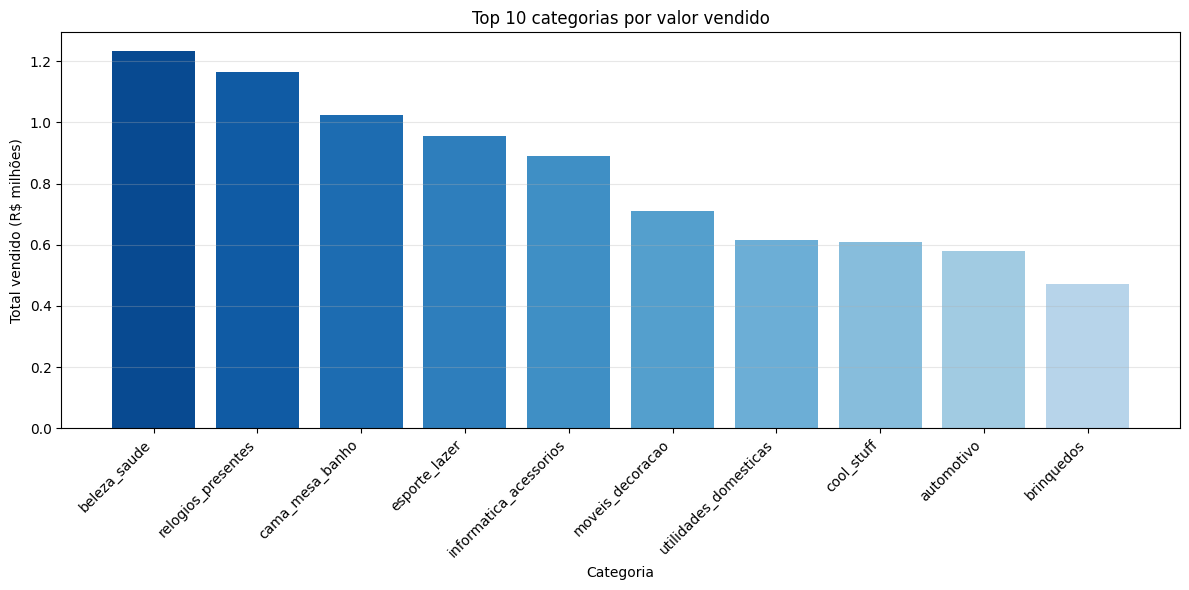

In [118]:
cores_degrade = [
    '#084a91', 
    '#105ba4', 
    '#1d6cb1', 
    '#2e7ebc', 
    '#3f8fc5', 
    '#549fcd', 
    '#6caed6', 
    '#87bddc', 
    '#a1cbe2', 
    '#b7d4ea']

plt.figure(figsize=(12,6))

plt.bar(df_top10_categorias["product_category_name"], df_top10_categorias["venda_total_categoria_milhoes"], color=cores_degrade)

plt.title("Top 10 categorias por valor vendido")
plt.xlabel("Categoria")
plt.ylabel("Total vendido (R$ milhões)")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()



**Insight:** A categoria `beleza_saude` apresentou o maior valor vendido, com aproximadamente **R$ 1,23 milhão**, seguida por `relogios_presentes`, com cerca de **R$ 1,17 milhão**, e `cama_mesa_banho`, com aproximadamente **R$ 1,02 milhão**.

### Categorias com maior quantidade de itens vendidos

Nesta análise, serão identificadas as categorias com maior quantidade de itens vendidos, considerando apenas os pedidos entregues.

In [119]:
df_qtde_categoria = df_itens_categoria.groupby("product_category_name")["product_id"].count().sort_values(ascending=False).reset_index()

df_qtde_categoria = df_qtde_categoria.rename(columns={"product_id": "quantidade_itens"})

df_top_10_qtde = df_qtde_categoria.head(10)

df_top_10_qtde

,product_category_name,quantidade_itens
0,cama_mesa_banho,10953
1,beleza_saude,9465
2,esporte_lazer,8431
3,moveis_decoracao,8160
4,informatica_acessorios,7644
5,utilidades_domesticas,6795
6,relogios_presentes,5859
7,telefonia,4430
8,ferramentas_jardim,4268
9,automotivo,4140


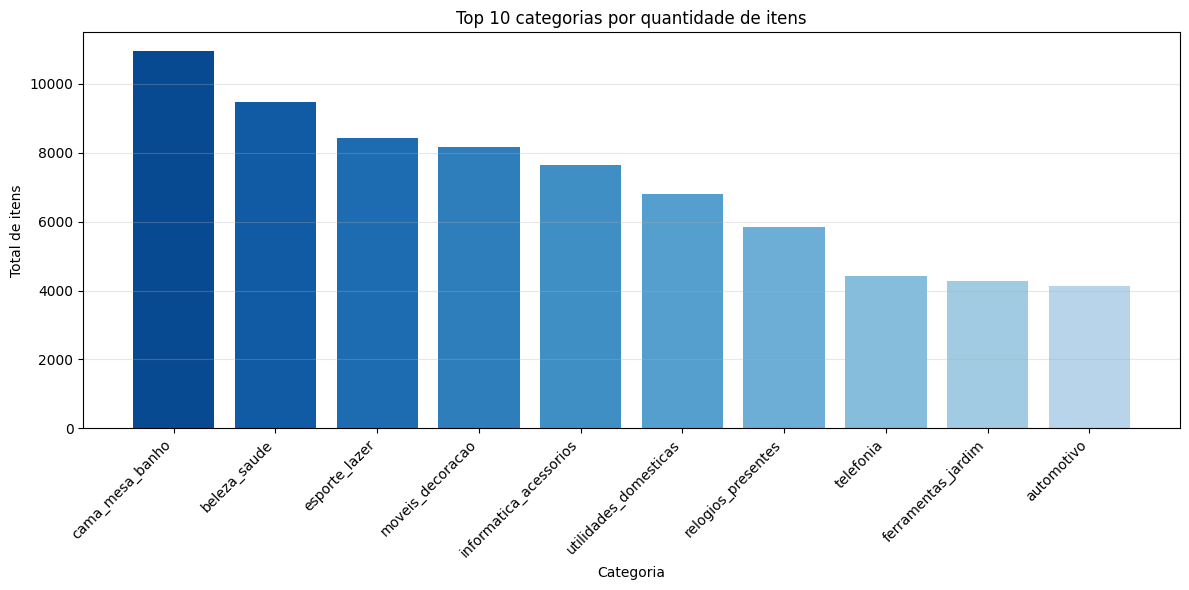

In [120]:
plt.figure(figsize=(12,6))

plt.bar(df_top_10_qtde["product_category_name"], df_top_10_qtde["quantidade_itens"], color=cores_degrade)

plt.title("Top 10 categorias por quantidade de itens")
plt.xlabel("Categoria")
plt.ylabel("Total de itens")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

**Insight:** `cama_mesa_banho` foi a categoria com maior quantidade de itens vendidos, totalizando **10.953 itens**, seguida por `beleza_saude`, com **9.465 itens**, e `esporte_lazer`, com **8.431 itens**. A comparação com a análise anterior mostra que uma maior quantidade de itens vendidos não significa, necessariamente, um maior valor total de vendas.

### Formas de pagamento mais utilizadas

Nesta seção, são considerados todos os pedidos presentes na tabela de pagamentos, independentemente do status do pedido.

In [123]:
df_formas_pagamento = df_pagamentos.groupby("payment_type")["order_id"].nunique().sort_values(ascending=False).reset_index()

df_formas_pagamento

,payment_type,order_id
0,credit_card,76505
1,boleto,19784
2,voucher,3866
3,debit_card,1528
4,not_defined,3


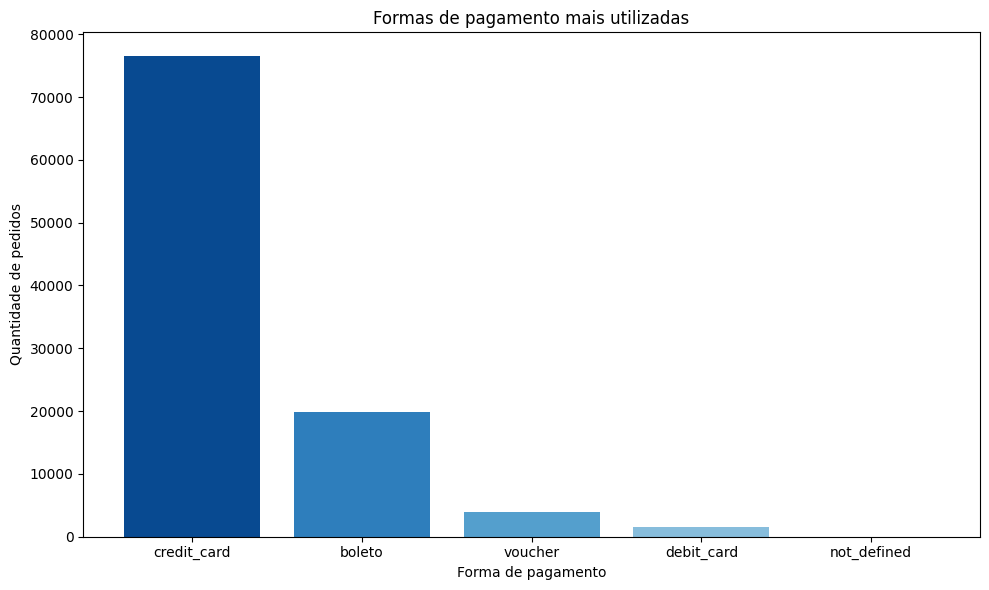

In [127]:
plt.figure(figsize=(10, 6))

plt.bar(df_formas_pagamento["payment_type"],df_formas_pagamento["order_id"], color=['#084a91', '#2e7ebc','#549fcd','#87bddc','#b7d4ea'])

plt.title("Formas de pagamento mais utilizadas")
plt.xlabel("Forma de pagamento")
plt.ylabel("Quantidade de pedidos")

plt.tight_layout()

plt.show()

**Insight:** O método de pagamento mais utilizado pelos clientes é o `credit_card`, presente em **76.505 pedidos**, seguido pelo `boleto`, utilizado em **19.784 pedidos**. O `voucher` aparece em terceiro lugar, presente em **3.866 pedidos**, demonstrando uma grande predominância do cartão de crédito em relação às demais formas de pagamento.

### Distribuição das avaliações dos clientes

Nesta análise, será avaliada a distribuição das notas atribuídas pelos clientes aos pedidos, considerando avaliações de 1 a 5.

In [135]:
df_distribuicao_avaliacoes = df_avaliacoes["review_score"].value_counts().sort_index().reset_index()

df_distribuicao_avaliacoes

,review_score,count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


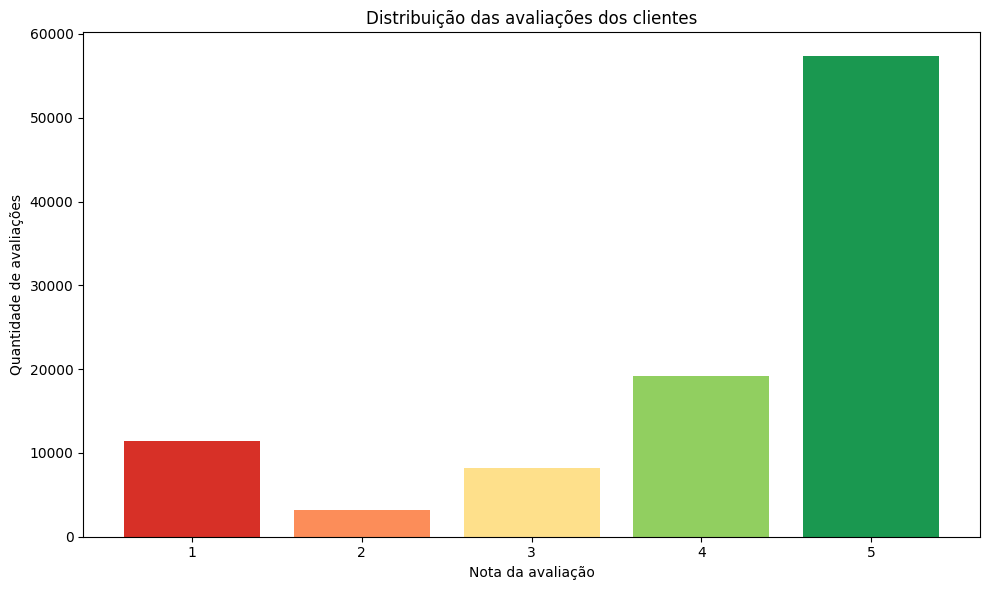

In [138]:
cores_avaliacoes = [
    "#d73027",
    "#fc8d59",
    "#fee08b",
    "#91cf60",
    "#1a9850"
]

plt.figure(figsize=(10, 6))

plt.bar(df_distribuicao_avaliacoes["review_score"],df_distribuicao_avaliacoes["count"], color=cores_avaliacoes)

plt.title("Distribuição das avaliações dos clientes")
plt.xlabel("Nota da avaliação")
plt.ylabel("Quantidade de avaliações")

plt.tight_layout()

plt.show()


**Insight:** A maior parte das avaliações é positiva, com destaque para a nota **5**, que possui **57.328 avaliações**, seguida pela nota **4**, com **19.142 avaliações**. Apesar da predominância de avaliações positivas, a nota **1** apresenta uma quantidade relevante, com **11.424 avaliações**, indicando a existência de um grupo significativo de clientes insatisfeitos.

### Relação entre atraso na entrega e avaliação do cliente

Nesta análise, será investigado se pedidos entregues após a data estimada apresentam avaliações diferentes dos pedidos entregues dentro do prazo.

In [ ]:
df_entrega = pd.merge(
    df_pedidos[["order_id", "order_delivered_customer_date", "order_estimated_delivery_date"]], 
    df_avaliacoes[["order_id", "review_score"]], 
    on="order_id"
)

df_entrega.head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,5


In [144]:
df_entrega.isna().sum()

order_id                            0
order_delivered_customer_date    2865
order_estimated_delivery_date       0
review_score                        0
dtype: int64

In [147]:
df_entrega = df_entrega.dropna()

df_entrega.isna().sum()

order_id                         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_score                     0
dtype: int64

In [155]:
df_entrega["atrasado"] = df_entrega["order_delivered_customer_date"] > df_entrega["order_estimated_delivery_date"] 

df_entrega["atrasado"].value_counts()

atrasado
False    88658
True      7701
Name: count, dtype: int64

In [162]:
df_avaliacao_atraso = df_entrega.groupby("atrasado")["review_score"].mean().reset_index()

df_avaliacao_atraso

,atrasado,review_score
0,False,4.293578
1,True,2.566550


In [165]:
situacao_entrega = {
    False: "No prazo",
    True: "Atrasado"
}

df_avaliacao_atraso["situacao_entrega"] = df_avaliacao_atraso["atrasado"].map(situacao_entrega)


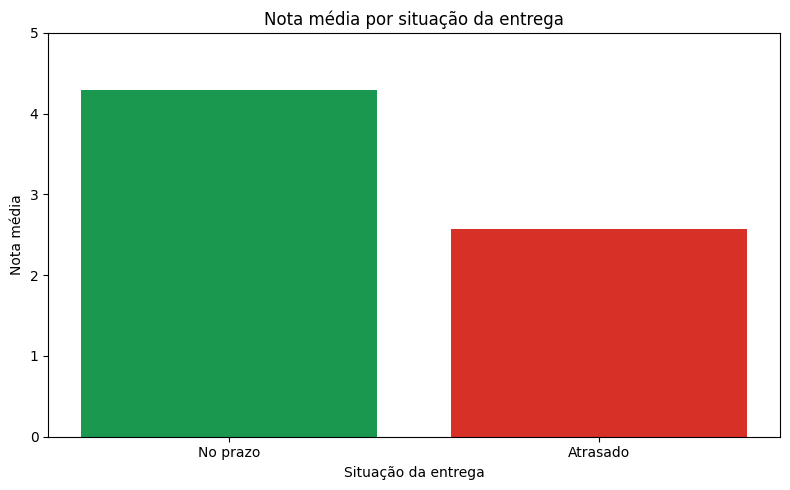

In [169]:
plt.figure(figsize=(8,5))

plt.bar(df_avaliacao_atraso["situacao_entrega"], df_avaliacao_atraso["review_score"], color=("#1a9850", "#d73027"))

plt.title("Nota média por situação da entrega")
plt.xlabel("Situação da entrega")
plt.ylabel("Nota média")
plt.ylim(0, 5)

plt.tight_layout()

plt.show()

**Insight:** A análise mostra uma relação entre o prazo de entrega e a avaliação dos clientes. Pedidos entregues no prazo apresentaram nota média de aproximadamente **4,29**, enquanto pedidos atrasados tiveram média de **2,57**. Essa diferença indica que os atrasos estão associados a avaliações mais baixas.

## Conclusão da análise exploratória

A análise exploratória permitiu identificar os principais padrões relacionados às vendas, categorias de produtos, formas de pagamento, avaliações dos clientes e desempenho das entregas.

Os resultados mostraram crescimento do valor vendido ao longo do período analisado, concentração das vendas em determinadas categorias e predominância do cartão de crédito como forma de pagamento. As avaliações dos clientes foram majoritariamente positivas, com destaque para a nota 5.

Também foi identificada uma relação entre o cumprimento do prazo de entrega e a satisfação dos clientes, já que pedidos entregues no prazo apresentaram avaliações médias superiores às dos pedidos atrasados.